In [ ]:
'''This is the first strategy to calculate the benefit of amitosis over mitosis.
Here we get the generation for the population mean fitness of mitotic population just decaying to 0.5 under different ploidies.
Then with this generation, get the slope of each replicate for both mitotic and amitotic populations under the corresponding
ploidies. Finally calculate the benefit of amitosis over mitosis as 1-kAmito/kMito

20190802:
Here based on strategy 1, we turned to get the slope of log population mean fitness for each replicates.'''

In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import os
import scipy as sp
from scipy import stats
import pickle
%matplotlib inline

### Get the generation that mitotic population fitness decaying to 0.5

In [2]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 4. Amito vs Mito_Benefit of Amito_N =10\2. Mito")

In [3]:
m10 = ['Fitness_WF_Mito_10_P2_L1_180827_10KG.csv', 'Fitness_WF_Mito_10_P4_L1_180827_10KG.csv', \
       'Fitness_WF_Mito_10_P8_L1_180827_10KG.csv','Fitness_WF_Mito_10_P16_L1_180827_10KG.csv', 
      'Fitness_WF_Mito_10_P32_L1_180827_10KG.csv', 'Fitness_WF_Mito_10_P45_L1_180827_10KG.csv',\
       'Fitness_WF_Mito_10_P64_L1_180827_10KG.csv', 'Fitness_WF_Mito_10_P128_L1_180827_10KG.csv']

In [4]:
m10_fit_mean = []
m10_fit_std = []

for i in m10:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
    
    var_mean = []
    var_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))

    m10_fit_mean.append(fit_mean)
    m10_fit_std.append(fit_std)

In [5]:
ploidy = [2,4,8,16,32, 45, 64, 128]

In [6]:
m10_f05_gen = []
m10_f05_fit = []


total_g =len(m10_fit_mean[0])

for i in range(8):
    for j in range(total_g):
        if m10_fit_mean[i][j-1]>0.5 and m10_fit_mean[i][j]<=0.5:
            print 'IJ05',i,j, m10_fit_mean[i][j-1], m10_fit_mean[i][j]
            m10_f05_gen.append([ploidy[i], j])
            m10_f05_fit.append([ploidy[i], m10_fit_mean[i][j]])  

IJ05 0 208 0.500714155896 0.499184777189
IJ05 1 353 0.500364159446 0.499052043465
IJ05 2 649 0.500160888615 0.499463716659
IJ05 3 1215 0.500059221005 0.499882238439
IJ05 4 2367 0.500050080915 0.499860916709
IJ05 5 3270 0.500033636126 0.499924869501
IJ05 6 4637 0.500061459819 0.499925851747
IJ05 7 9246 0.500041848518 0.49999775965


In [7]:
m10_f05_gen

[[2, 208],
 [4, 353],
 [8, 649],
 [16, 1215],
 [32, 2367],
 [45, 3270],
 [64, 4637],
 [128, 9246]]

In [8]:
m10_f05_fit

[[2, 0.49918477718851989],
 [4, 0.49905204346450616],
 [8, 0.49946371665947342],
 [16, 0.49988223843903562],
 [32, 0.4998609167093907],
 [45, 0.4999248695005058],
 [64, 0.4999258517470711],
 [128, 0.49999775964981941]]

### Get the slope of each mitotic replicate at generation that mitotic population fitness decaying to 0.5

In [9]:
m10_f05_gen_1 = [i[1] for i in m10_f05_gen]
print 'F05', m10_f05_gen_1

F05 [208, 353, 649, 1215, 2367, 3270, 4637, 9246]


In [10]:
def transform_fit_log(fit_file):
    '''This function is used to read data from fit_file, and transform it to the fitness dynamics of each replicate,
    and then converted it into log10 form'''
    
    with open(fit_file, 'rb') as f:
        fit = pickle.load(f)
        
    fit = np.array(fit)
    
    log_fit = np.log10(fit)
        
    new_fit = []
    for i in range(len(log_fit[0])):
        ind_new_fit = []
        for j in range(len(log_fit)):
            ind_new_fit.append(log_fit[j][i])
        new_fit.append(ind_new_fit)
        
    return new_fit

In [12]:
def get_slope(gen, new_fit):
    '''Do the linear regression for each replicate'''
    
    slope_list = []

    for i in range(len(new_fit)):
        slope = sp.stats.linregress(np.arange(gen+1), new_fit[i][:(gen+1)])[0]
        slope_list.append(slope)
        
    slope = np.array(slope_list)
    return slope

In [13]:
def calculate_slope_log(fit_file, gen):
    new_fit = transform_fit_log(fit_file)
    slope = get_slope(gen, new_fit)
    return slope

In [14]:
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)    

In [15]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 4. Amito vs Mito_Benefit of Amito_N =10\2. Mito")

In [16]:
m10_f05_gen = np.array(m10_f05_gen)
m10_f05_gen

array([[   2,  208],
       [   4,  353],
       [   8,  649],
       [  16, 1215],
       [  32, 2367],
       [  45, 3270],
       [  64, 4637],
       [ 128, 9246]])

In [19]:
mito_p2_fit = transform_fit_log('M10_P2_Pop_Mean_Fit')

In [28]:
mito_p2_slope = sp.stats.linregress(np.arange(209), mito_p2_fit[-1][:209])[0]
mito_p2_slope

-0.00112697959567146

In [31]:
len(m10_slope[0])

100

In [34]:
amito_p2_fit = transform_fit_log('A10_P2_Pop_Mean_Fit')

In [41]:
amito_p2_slope = sp.stats.linregress(np.arange(209), amito_p2_fit[69][:209])[0]
amito_p2_slope

-0.00079754059214876005

In [43]:
a10_slope[0][69]

-0.00079754059214876005

In [59]:
for i in range(len(ploidy)):
    mito_slope = calculate_slope_log('M10_P{}_Pop_Mean_Fit'.format(ploidy[i]), m10_f05_gen_1[i])
    save_object(mito_slope, 'M10_P{}_log_Slope_1'.format(ploidy[i]))

In [33]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 4. Amito vs Mito_Benefit of Amito_N =10\1. Amito")

In [43]:
for i in range(len(ploidy)):
    amito_slope = calculate_slope_log('A10_P{}_Pop_Mean_Fit'.format(ploidy[i]), m10_f05_gen_1[i])
    save_object(amito_slope, 'A10_P{}_log_Slope_1'.format(ploidy[i]))

In [52]:
import numpy as np
from numpy import random
import os
import pickle

In [44]:
def bootstrap(slope1, slope2, repeat_times):
    
    assert len(slope1) == len(slope2)
    n = len(slope1)
    
    total_benefit = []
    
    for i in range(repeat_times):
        
        sel_index1= []
        while len(sel_index1)<n:
            sel_index1.append(random.randint(0, n))
#         print len(sel_index1), sel_index1
        
        sel_index2= []
        while len(sel_index2)<n:
            sel_index2.append(random.randint(0, n))   
            
#         print len(sel_index2), sel_index2
        
        sel_slope1 = [slope1[j] for j in sel_index1]
        sel_slope2 = [slope2[k] for k in sel_index2]
#         print 'SS1', len(sel_slope1)
#         print 'SS2', len(sel_slope2)
        
        sel_slope1 = np.array(sel_slope1)
        sel_slope2 = np.array(sel_slope2)
        
        benefit = np.nanmean(1- sel_slope1/sel_slope2)
        total_benefit.append(benefit)
        
    
    total_benefit = np.array(total_benefit)
    
    final_mean = np.nanmean(total_benefit)
    final_lower = np.percentile(total_benefit, 2.5)
    final_upper = np.percentile(total_benefit, 97.5)

    confidence_range = [final_lower, final_upper]
    
    return final_mean, final_lower, final_upper, confidence_range

In [45]:
def read_file(file_list):
    
    total_list = []
    for i in file_list:
        with open(i, 'rb') as f:
            x = pickle.load(f)
            total_list.append(x)
    return total_list

In [36]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 4. Amito vs Mito_Benefit of Amito_N =10\1. Amito\Strategy 1 log slope")

In [46]:
a10_file = ['A10_P2_log_Slope_1', 'A10_P4_log_Slope_1', 'A10_P8_log_Slope_1', 'A10_P16_log_Slope_1', 'A10_P32_log_Slope_1',\
            'A10_P45_log_Slope_1', 'A10_P64_log_Slope_1', 'A10_P128_log_Slope_1']

In [47]:
a10_slope = read_file(a10_file)

In [48]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 4. Amito vs Mito_Benefit of Amito_N =10\2. Mito\Strategy 1 log slope")

In [49]:
m10_file = ['M10_P2_log_Slope_1', 'M10_P4_log_Slope_1', 'M10_P8_log_Slope_1', 'M10_P16_log_Slope_1', 'M10_P32_log_Slope_1' ,\
            'M10_P45_log_Slope_1', 'M10_P64_log_Slope_1', 'M10_P128_log_Slope_1']

In [50]:
m10_slope = read_file(m10_file)

In [53]:
total_mean = []
total_lower = []
total_upper = []
total_crange = []

for i in range(len(a10_slope)):
    result = bootstrap(a10_slope[i], m10_slope[i], 10000)
    total_mean.append(result[0])
    total_lower.append(result[1])
    total_upper.append(result[2])
    total_crange.append(result[3])

In [54]:
total_mean

[0.38877044990227816,
 0.52848775705594364,
 0.56786603957519077,
 0.5502994882965101,
 0.61633485853005454,
 0.639002716190606,
 0.60500509481644571,
 0.59436611236866443]

In [55]:
total_lower

[0.31081234651110257,
 0.46366374557171053,
 0.51158284187200276,
 0.49442206633165908,
 0.56250896106099046,
 0.59256490573984932,
 0.55421621012444899,
 0.54286960723009003]

In [56]:
total_upper

[0.46270415242117025,
 0.58860270724304875,
 0.62195283642840393,
 0.60553732765860668,
 0.66793839752973694,
 0.68466834703994117,
 0.65416064843807764,
 0.64544666767750658]

In [72]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

# Slope to the generation of mitotic population that just below 0.5

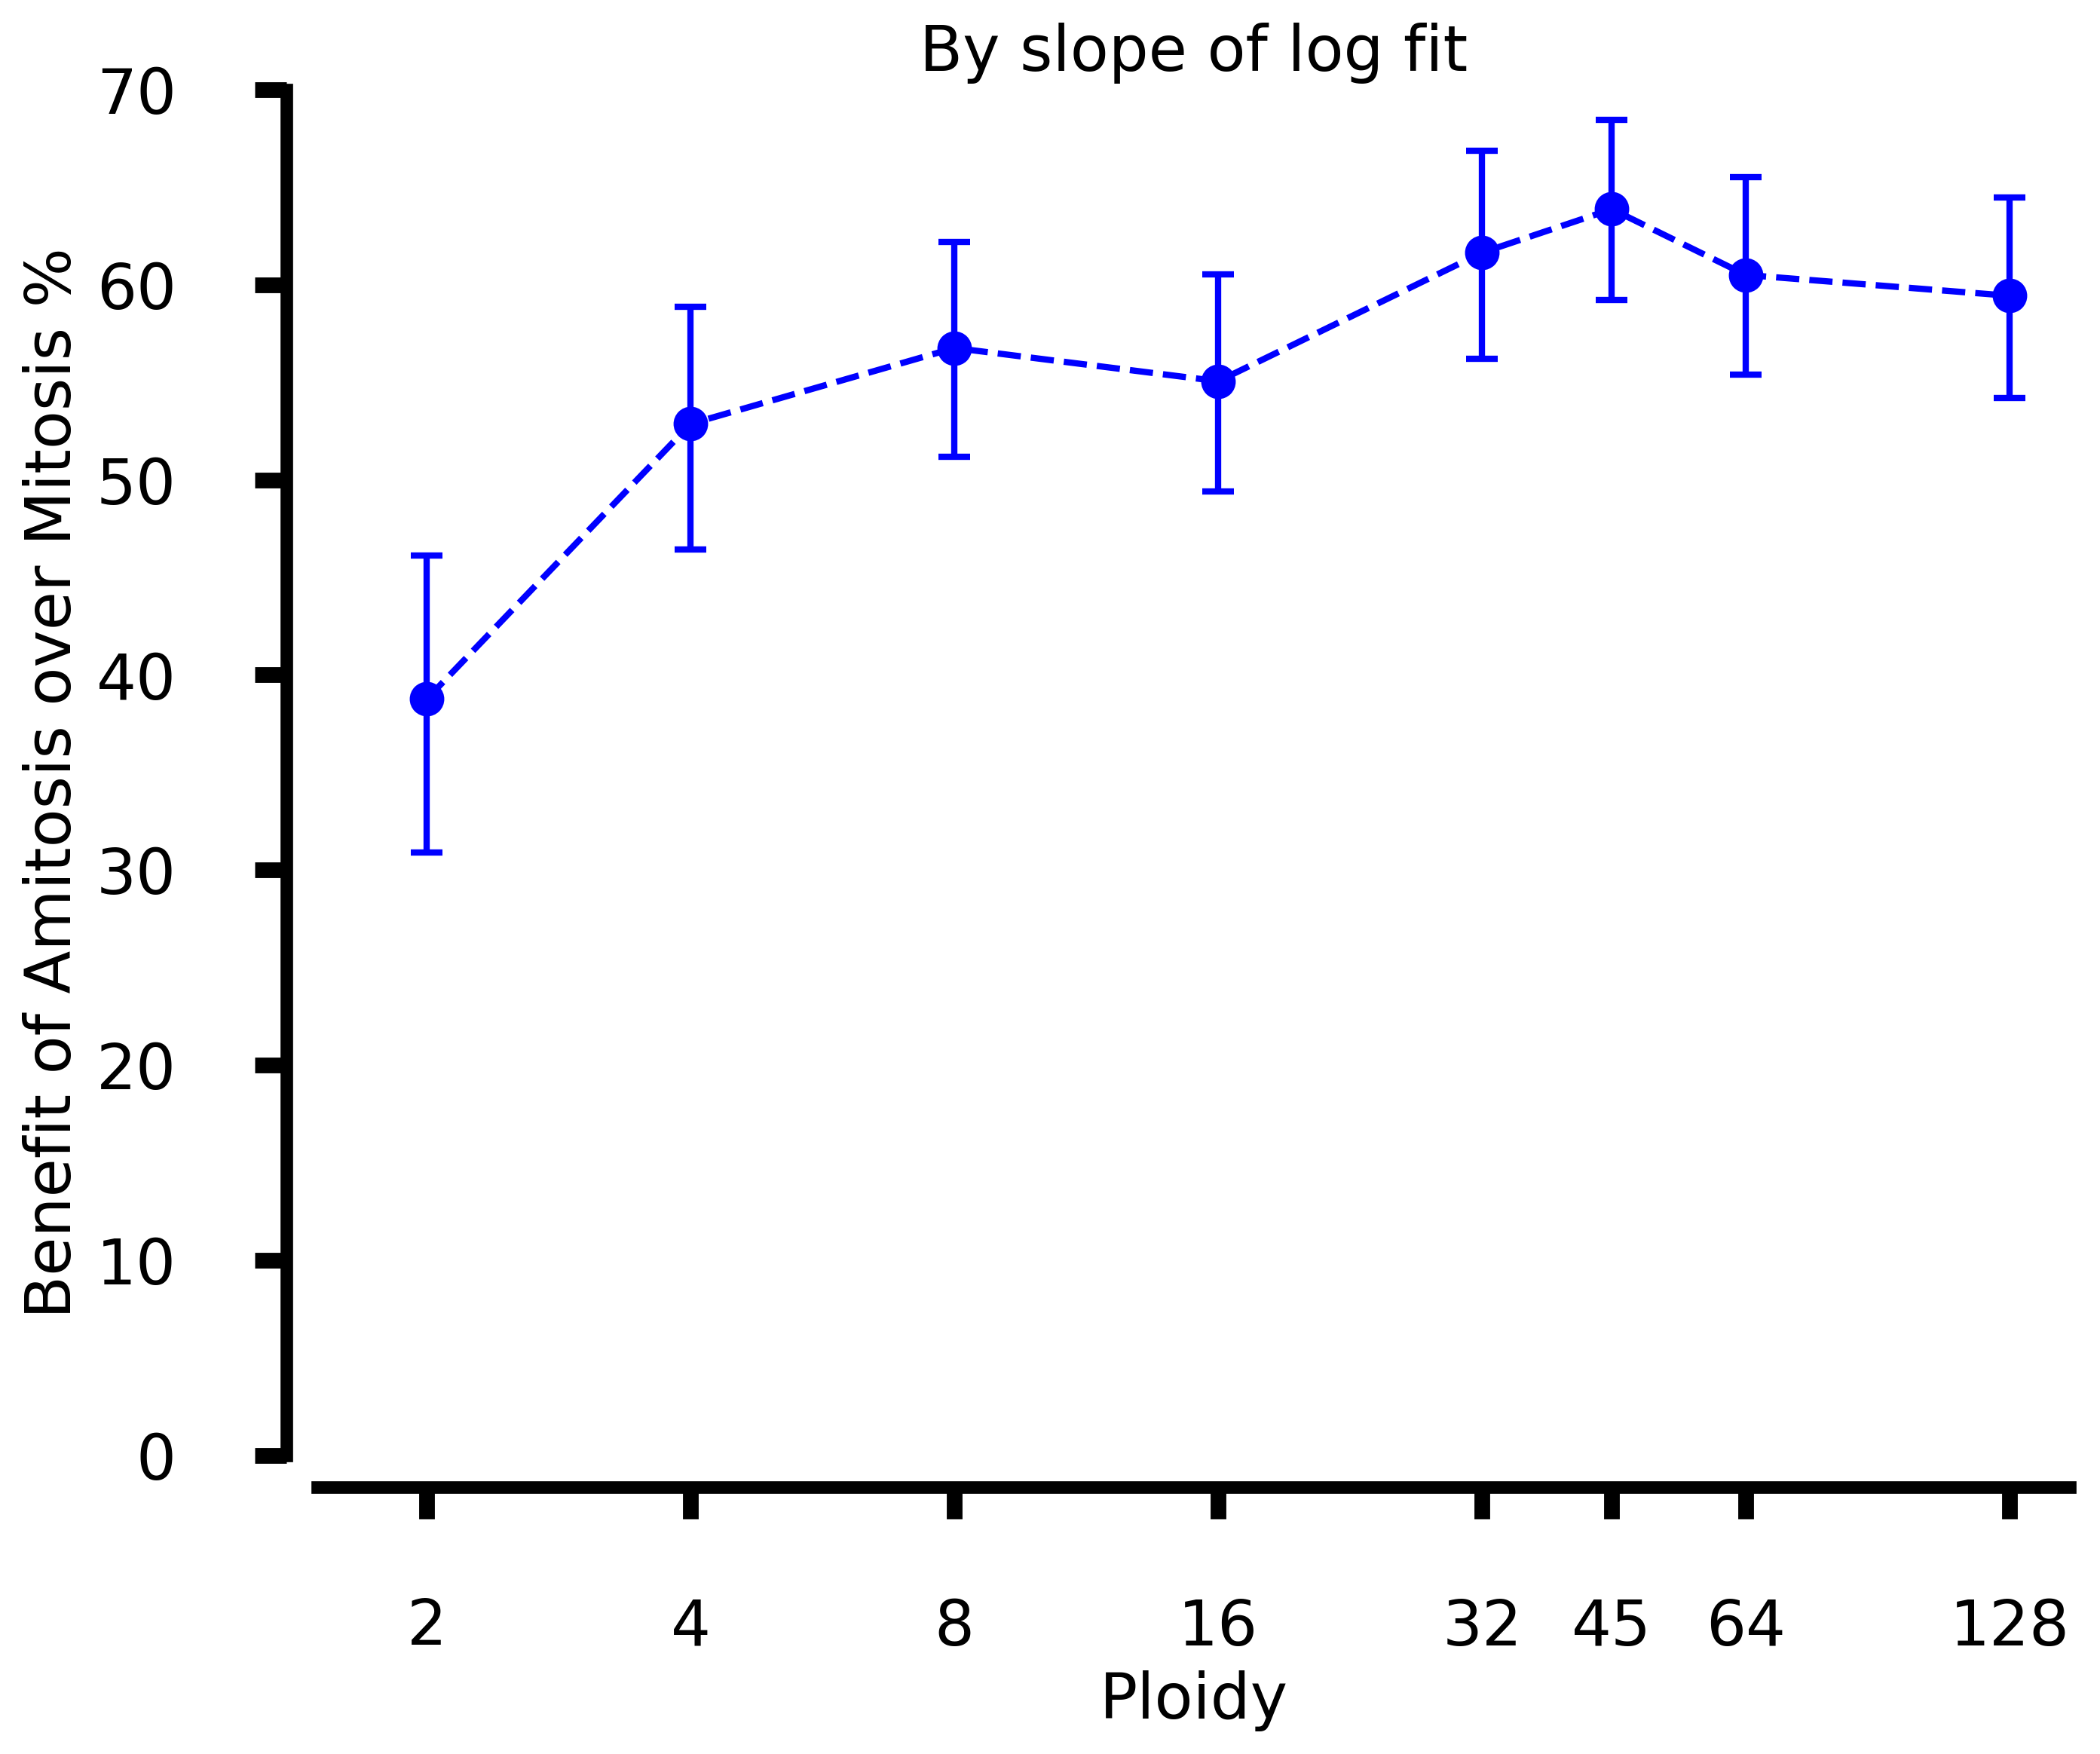

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(10, 8), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_ylim(0, 0.7)
ax.set_xlim(1.5,150)

x = [2,4,8,16, 32, 45, 64, 128]
ax.set_xscale('log',basex=2)

mean = total_mean
lower_error = list(np.array(total_mean) -np.array(total_lower))
upper_error = list(np.array(total_upper) -np.array(total_mean))


plt.errorbar(x, mean, yerr=[lower_error, upper_error], color ='b',fmt='o', ls = '--',markersize =10, lw=2, capsize=5, capthick=2)

ax.set_title('By slope of log fit', fontsize = 20)
ax.set_xlabel('Ploidy', fontsize =20)
ax.set_ylabel('Benefit of Amitosis over Mitosis % ', fontsize =20)

ax.set_xticks([2,4,8, 16, 32, 45, 64, 128]) # choose which x locations to have ticks
ax.set_xticklabels([2,4,8, 16, 32, 45, 64, 128]) # set the labels to display at those ticks

ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]) # choose which x locations to have ticks
ax.set_yticklabels([0, 10, 20, 30, 40, 50, 60, 70]) # set the labels to display at those ticks